# 04 — SOC QAOA: Spin Hall Material Selection

> **spinq-vqe** | Workstream B2 · ARPA QONDRA

Use a classical MLP surrogate (trained on spin Hall angle data) as the oracle
for a QAOA circuit that selects the optimal k-material heterostructure.

## Problem statement

Given **N spintronic candidate materials**, each with a predicted spin Hall angle θ_SH(i),
find the **k-material heterostructure** that maximises the total θ_SH:

$$\text{maximise} \quad \sum_{i} x_i \cdot \theta_{\text{SH}}(i) \quad\text{subject to}\quad \sum_i x_i = k,\; x_i\in\{0,1\}$$

QUBO encoding: $x_i = (1 - Z_i)/2$. Cost Hamiltonian:

$$H_C = -\frac{1}{2}\sum_i w_i Z_i + \lambda\left(\sum_i Z_i - (N-2k)\right)^2$$

Standard transverse-field mixer: $H_M = \sum_i X_i$

## Pipeline

```
Mock dataset (12 materials)  →  MLP surrogate  →  θ_SH predictions
→  QUBO Hamiltonian  →  QAOA (p=1,2,3)  →  Material ranking
```

### References
- Farhi et al. (2014) arXiv:1411.4028 — QAOA
- Sinova et al. (2015) Rev. Mod. Phys. 87, 1213 — spin Hall effect review
- Lucas (2014) Front. Phys. 2, 5 — QUBO encoding

In [1]:
from __future__ import annotations
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from spinq_vqe import surrogate, qaoa

os.makedirs('../data',    exist_ok=True)
os.makedirs('../figures', exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#EBEBEB', 'grid.linewidth': 0.7,
    'figure.dpi': 110,
})

# Pastel palette (consistent with project)
PAL = dict(qaoa='#7EB8D4', greedy='#C7E4CA', sa='#EBD8DC',
           actual='#756F6A', pred='#DBD3DC', line='#F0D9CC')

print('Imports OK')

Imports OK


---
## 1. Dataset

In [2]:
ds = surrogate.load_mock_data()
print(f'Dataset: {ds.n_samples} materials')
print(f'{"#":>3}  {"Formula":>10}  {"Crystal":>12}  {"Z_max":>5}  {"AHC (S/cm)":>10}  {"θ_SH":>7}')
print('-' * 60)
for i, r in enumerate(ds.records):
    print(f'{i:>3}  {r.formula:>10}  {r.crystal_system:>12}  {r.z_max:>5}  {r.ahc:>10.1f}  {r.theta_sh:>7.3f}')

Dataset: 12 materials
  #     Formula       Crystal  Z_max  AHC (S/cm)     θ_SH
------------------------------------------------------------
  0       Mn3Sn     hexagonal     50       200.0    0.350
  1          Pt         cubic     78         0.0    0.080
  2           W         cubic     74         0.0   -0.330
  3          Ta         cubic     73         0.0   -0.120
  4          Pd         cubic     46         0.0    0.010
  5          Au         cubic     79         0.0    0.110
  6     Co2MnGa         cubic     31      1600.0    0.200
  7       Fe3Sn     hexagonal     50       450.0    0.250
  8       IrMn3         cubic     77         0.0    0.180
  9       CrTe2      trigonal     52       320.0    0.400
 10        MnPt    tetragonal     78       150.0    0.150
 11      Bi2Se3      trigonal     83         0.0    3.500


---
## 2. Train MLP surrogate

Surrogate: sklearn MLP  |  features: 6  |  CV R²: n/a

Actual   θ_SH range: [-0.330, 3.500]
Predicted θ_SH range: [-0.219, 3.513]
RMSE (train):  0.0450


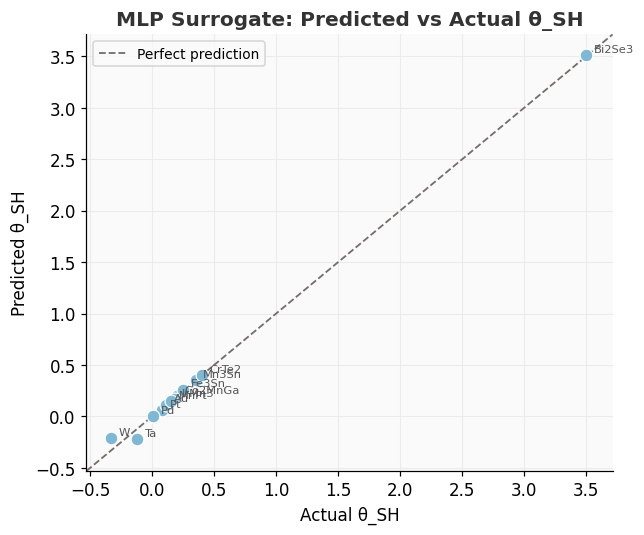

Saved → figures/surrogate_predictions.png


In [3]:
sr = surrogate.train_surrogate(ds, hidden_layer_sizes=(64, 32), max_iter=3000, random_state=0)
surrogate.surrogate_summary(sr)

# Predicted vs actual
theta_pred = surrogate.predict(sr, ds.records)
theta_true = ds.theta_sh_values
formulas   = ds.formulas

print(f'\nActual   θ_SH range: [{theta_true.min():.3f}, {theta_true.max():.3f}]')
print(f'Predicted θ_SH range: [{theta_pred.min():.3f}, {theta_pred.max():.3f}]')

residuals = theta_pred - theta_true
rmse = float(np.sqrt(np.mean(residuals**2)))
print(f'RMSE (train):  {rmse:.4f}')

# Scatter plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(theta_true, theta_pred, color=PAL['qaoa'], s=70, zorder=3, edgecolors='white', linewidths=0.8)
lim = (min(theta_true.min(), theta_pred.min()) - 0.2,
       max(theta_true.max(), theta_pred.max()) + 0.2)
ax.plot(lim, lim, '--', color=PAL['actual'], lw=1.2, label='Perfect prediction')
for i, f in enumerate(formulas):
    ax.annotate(f, (theta_true[i], theta_pred[i]),
                textcoords='offset points', xytext=(5, 2), fontsize=7.5, color='#555')
ax.set_xlabel('Actual θ_SH')
ax.set_ylabel('Predicted θ_SH')
ax.set_title('MLP Surrogate: Predicted vs Actual θ_SH', fontweight='semibold', color='#333')
ax.legend(fontsize=9)
ax.set_xlim(lim); ax.set_ylim(lim)
plt.tight_layout()
plt.savefig('../figures/surrogate_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/surrogate_predictions.png')

---
## 3. QAOA setup

Select **k=3** materials from the **N=12** candidates.
Constraint penalty λ=5 > max(|θ_SH|) = 3.5 (Bi₂Se₃).

In [4]:
N_MAT = ds.n_samples    # 12 candidate materials
K     = 3               # heterostructure layers to select
LAM   = 6.0             # penalty: > max(|theta_sh|)

# Use surrogate predictions as oracle weights
theta_oracle = theta_pred.copy()

print(f'Optimization problem: choose {K} from {N_MAT} materials')
print(f'Max θ_SH (greedy): {qaoa.classical_greedy(theta_oracle, K)["total"]:.4f}')
print(f'Constraint penalty λ = {LAM}')
print(f'QAOA Hilbert space: 2^{N_MAT} = {2**N_MAT} states')
print()
print(f'  Oracle θ_SH values:')
for i, (f, t) in enumerate(zip(formulas, theta_oracle)):
    print(f'    {i:>2}  {f:>10}  {t:>+7.4f}')

Optimization problem: choose 3 from 12 materials
Max θ_SH (greedy): 4.2626
Constraint penalty λ = 6.0
QAOA Hilbert space: 2^12 = 4096 states

  Oracle θ_SH values:
     0       Mn3Sn  +0.3494
     1          Pt  +0.0581
     2           W  -0.2138
     3          Ta  -0.2191
     4          Pd  +0.0027
     5          Au  +0.1154
     6     Co2MnGa  +0.1987
     7       Fe3Sn  +0.2607
     8       IrMn3  +0.1675
     9       CrTe2  +0.3998
    10        MnPt  +0.1472
    11      Bi2Se3  +3.5134


---
## 4. Run QAOA at p = 1, 2, 3

COBYLA optimizer, 5 random seeds, 300 evaluations per seed.

In [5]:
qaoa_results = {}

for p in [1, 2, 3]:
    print(f'\n--- QAOA p={p} ---')
    res = qaoa.run_qaoa(
        theta_oracle, k=K, p=p, lam=LAM,
        n_optimizer_steps=300, n_seeds=5, step_size=0.3,
        verbose=True,
    )
    qaoa_results[p] = res
    qaoa.qaoa_summary(res, formulas)

print('\nAll QAOA runs complete')


--- QAOA p=1 ---


  seed=0  E=-178.998649  evals=300


  seed=1  E=-146.096098  evals=28


  seed=2  E=-170.810943  evals=300


  seed=3  E=-214.770857  evals=31


...

  seed=0  E=-125.544348  evals=300


  seed=1  E=-221.192338  evals=300


  seed=2  E=-238.643242  evals=89


  seed=3  E=-167.901097  evals=248


  seed=4  E=-85.498698  evals=139

Selected: [0, 9, 11]
Total theta_SH: 4.2626  (greedy: 4.2626)
QAOA depth p=3  |  N=12  k=3
Best QAOA energy: -238.643242
Selected indices: [0, 9, 11]
Selected formulas: ['Mn3Sn', 'CrTe2', 'Bi2Se3']
Total theta_SH:  4.2626

All QAOA runs complete


---
## 5. Classical baselines: greedy and simulated annealing

In [6]:
greedy = qaoa.classical_greedy(theta_oracle, K)
sa     = qaoa.classical_simulated_annealing(theta_oracle, K, n_steps=20_000, seed=0)

print('=== Classical baselines ===')
print(f'Greedy (top-{K}):  idx={greedy["selected_indices"]}  '
      f'formulas={[formulas[i] for i in greedy["selected_indices"]]}  '
      f'θ_SH={greedy["total"]:.4f}')
print(f'Simulated annealing: idx={sa["selected_indices"]}  '
      f'formulas={[formulas[i] for i in sa["selected_indices"]]}  '
      f'θ_SH={sa["total"]:.4f}')

=== Classical baselines ===
Greedy (top-3):  idx=[11, 9, 0]  formulas=['Bi2Se3', 'CrTe2', 'Mn3Sn']  θ_SH=4.2626
Simulated annealing: idx=[np.int64(0), np.int64(9), np.int64(11)]  formulas=['Mn3Sn', 'CrTe2', 'Bi2Se3']  θ_SH=4.2626


---
## 6. Results comparison

=== Results summary ===
              Method  Total θ_SH                        Selected
-----------------------------------------------------------------
  QAOA p=             1      3.0804           ['W', 'Ta', 'Bi2Se3']
  QAOA p=             2      4.2626    ['Mn3Sn', 'CrTe2', 'Bi2Se3']
  QAOA p=             3      4.2626    ['Mn3Sn', 'CrTe2', 'Bi2Se3']
                Greedy      4.2626    ['Bi2Se3', 'CrTe2', 'Mn3Sn']
   Simulated Annealing      4.2626    ['Mn3Sn', 'CrTe2', 'Bi2Se3']


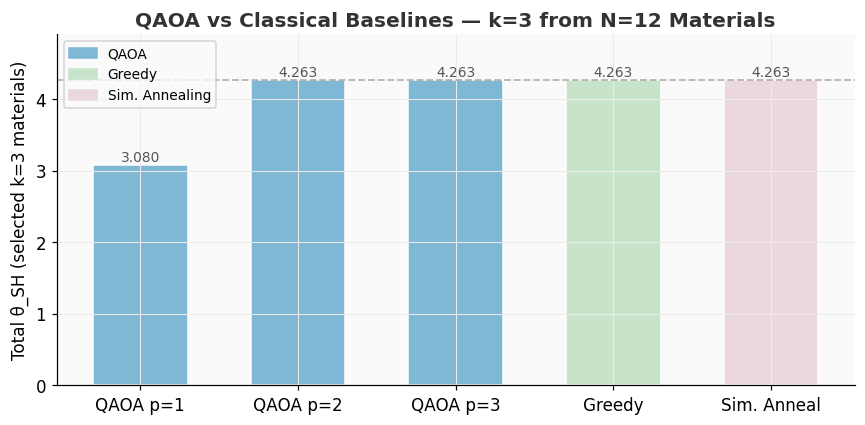

Saved → figures/qaoa_comparison.png


In [7]:
print('=== Results summary ===')
print(f'{"Method":>20}  {"Total θ_SH":>10}  {"Selected":>30}')
print('-' * 65)
for p in [1, 2, 3]:
    res = qaoa_results[p]
    sel = [formulas[i] for i in res.selected_indices]
    print(f'  QAOA p={p:>14}  {res.selected_theta_sh:>10.4f}  {str(sel):>30}')
print(f'  {"Greedy":>20}  {greedy["total"]:>10.4f}  '
      f'{str([formulas[i] for i in greedy["selected_indices"]]):>30}')
print(f'  {"Simulated Annealing":>20}  {sa["total"]:>10.4f}  '
      f'{str([formulas[i] for i in sa["selected_indices"]]):>30}')

# Bar chart: total θ_SH by method
methods = [f'QAOA p={p}' for p in [1,2,3]] + ['Greedy', 'Sim. Anneal']
totals  = [qaoa_results[p].selected_theta_sh for p in [1,2,3]] + [greedy['total'], sa['total']]
colors  = [PAL['qaoa']]*3 + [PAL['greedy'], PAL['sa']]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(methods, totals, color=colors, edgecolor='white', width=0.6)
ax.axhline(greedy['total'], color=PAL['actual'], lw=1.2, ls='--', alpha=0.5, label='Greedy (optimal)')
for bar, val in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, color='#555')
ax.set_ylabel('Total θ_SH (selected k=3 materials)')
ax.set_title(f'QAOA vs Classical Baselines — k={K} from N={N_MAT} Materials',
             fontweight='semibold', color='#333')
ax.set_ylim(0, max(totals)*1.15)
patches = [mpatches.Patch(color=PAL['qaoa'], label='QAOA'),
           mpatches.Patch(color=PAL['greedy'], label='Greedy'),
           mpatches.Patch(color=PAL['sa'], label='Sim. Annealing')]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.savefig('../figures/qaoa_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/qaoa_comparison.png')

---
## 7. QAOA convergence curves

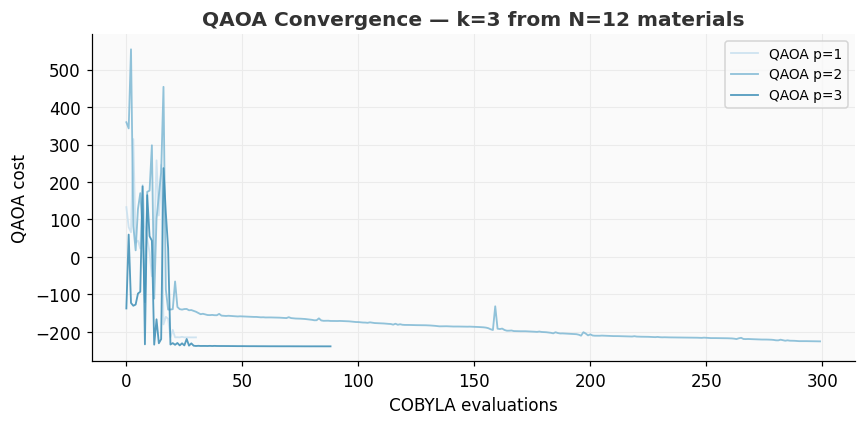

Saved → figures/qaoa_convergence.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
blues = ['#C8E0EF', '#7EB8D4', '#3A8DB5']
for (p, res), col in zip(qaoa_results.items(), blues):
    h = res.energy_history
    ax.plot(range(len(h)), h, lw=1.2, color=col, alpha=0.85, label=f'QAOA p={p}')

ax.set_xlabel('COBYLA evaluations')
ax.set_ylabel('QAOA cost')
ax.set_title('QAOA Convergence — k=3 from N=12 materials', fontweight='semibold', color='#333')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../figures/qaoa_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/qaoa_convergence.png')

---
## 8. Material ranking visualisation

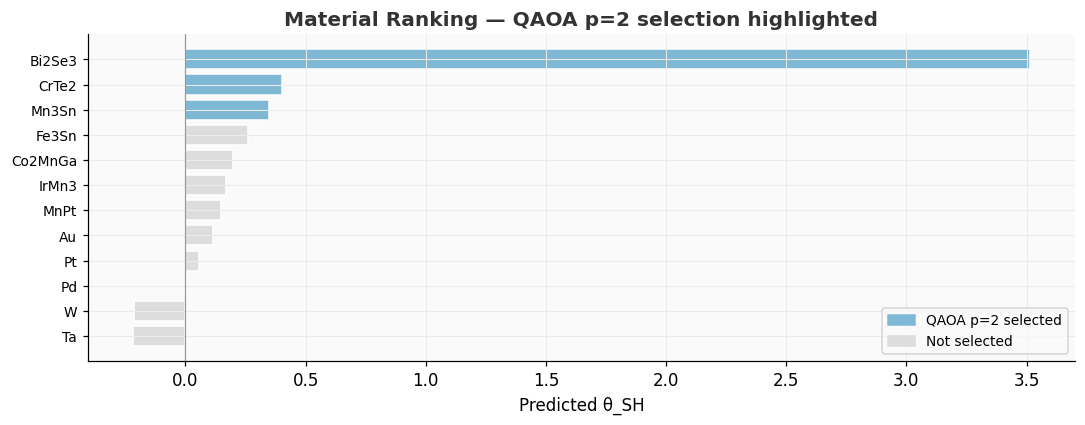

Saved → figures/qaoa_material_ranking.png
Best QAOA (p=2) selected: ['Mn3Sn', 'CrTe2', 'Bi2Se3']
Total θ_SH = 4.2626  |  Greedy = 4.2626


In [9]:
# Best QAOA result (highest p)
best_p   = max(qaoa_results, key=lambda p: qaoa_results[p].selected_theta_sh)
best_res = qaoa_results[best_p]
selected_idx = set(best_res.selected_indices)

sort_idx = np.argsort(theta_oracle)[::-1]
sorted_formulas = [formulas[i] for i in sort_idx]
sorted_theta    = theta_oracle[sort_idx]
bar_colors      = [PAL['qaoa'] if sort_idx[i] in selected_idx else '#DDDDDD'
                   for i in range(len(sort_idx))]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(range(N_MAT), sorted_theta, color=bar_colors, edgecolor='white')
ax.set_yticks(range(N_MAT))
ax.set_yticklabels(sorted_formulas, fontsize=9)
ax.axvline(0, color='#999', lw=0.8)
ax.set_xlabel('Predicted θ_SH')
ax.set_title(f'Material Ranking — QAOA p={best_p} selection highlighted',
             fontweight='semibold', color='#333')
qaoa_patch   = mpatches.Patch(color=PAL['qaoa'],  label=f'QAOA p={best_p} selected')
unsel_patch  = mpatches.Patch(color='#DDDDDD',    label='Not selected')
ax.legend(handles=[qaoa_patch, unsel_patch], fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../figures/qaoa_material_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → figures/qaoa_material_ranking.png')
print(f'Best QAOA (p={best_p}) selected: {[formulas[i] for i in best_res.selected_indices]}')
print(f'Total θ_SH = {best_res.selected_theta_sh:.4f}  |  Greedy = {greedy["total"]:.4f}')

---
## 9. Save results

In [10]:
import csv

rows = []
for p in [1, 2, 3]:
    res = qaoa_results[p]
    rows.append({
        'method': f'QAOA_p{p}', 'k': K, 'N': N_MAT,
        'total_theta_sh': f'{res.selected_theta_sh:.6f}',
        'selected_idx': str(res.selected_indices),
        'selected_formulas': str([formulas[i] for i in res.selected_indices]),
        'evals': len(res.energy_history),
    })
for name, baseline in [('Greedy', greedy), ('SA', sa)]:
    rows.append({
        'method': name, 'k': K, 'N': N_MAT,
        'total_theta_sh': f'{baseline["total"]:.6f}',
        'selected_idx': str(baseline['selected_indices']),
        'selected_formulas': str([formulas[i] for i in baseline['selected_indices']]),
        'evals': 'N/A',
    })

with open('../data/qaoa_results.csv', 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

print('Saved → data/qaoa_results.csv')
print()
print('=== NB04 complete ===')

Saved → data/qaoa_results.csv

=== NB04 complete ===


---
*spinq-vqe / ARPA QONDRA — Notebook 04*